In [19]:
import os, json, re
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
path_gt_args = "..\\Data\\Annotations"

gt     = "annotations"        
models = ["qwen2.5-3b","gemma3-4b","gemma3-27b","llama3.3-70b","deepseek-r1-70b",
          "only_M_and_L_models", 'annotations']

## TF-IDF de argumentos para mapas de calor

Rows (Goal/SDG): each SDG (0–17).
Columns (Model): the models + gold annotations.
Cell value: the mean TF-IDF score of SDG-specific keywords over arguments classified for that goal.

So a high value means: The arguments assigned to this SDG by that model contain a higher relative weight of the keywords you listed for that SDG.

Interpretation:
- Not a measure of frequency (TF-IDF doesn't say how much SDG 5 is discussed overall).
- A measure of keyword salience: it says how strongly the arguments for SDGx are anchored in the chosen SDGx keywords compared to other goals.


In [40]:
# -----------------------------
# 1. Keyword dictionary (Goal 1)
# -----------------------------
keywords_g1 = {
    "in_favor": [
        "poverty reduction", "poverty alleviation", "social protection", "economic empowerment",
        "wealth creation", "opportunity", "prosperity", "development aid", "microfinance",
        "basic income", "empowerment", "upliftment", "sufficiency", "inclusion", "equity"
    ],
    "against": [
        "poverty", "pennilessness", "distress", "necessity", "hardship", "insolvency",
        "privation", "penury", "destitution", "hand-to-mouth existence", "beggary",
        "indigence", "pauperism", "necessitousness", "extreme poverty", "wealth inequality",
        "exploitation", "lack of opportunity", "exclusion", "vulnerability",
        "deprivation", "marginalization"
    ]
}

keywords_g2 = {
    "in_favor": [
        "food security", "food", "nutrition", "zero hunger", "nourishment",
        "food sovereignty", "food aid", "school feeding programs",
        "access to food", "healthy diets"
    ],
    "against": [
        "hunger", "undernutrition", "malnutrition", "starvation", "famine",
        "undernourishment", "food insecurity", "food waste", "crop failure",
        "land grabbing", "price volatility", "nutrient deficiency"
    ]
}

keywords_g3 = {
    "in_favor": [
        "wellbeing", "welfare", "health", "benefit", "advantage", "comfort",
        "happiness", "prosperity", "universal health coverage", "healthcare access",
        "disease prevention", "mental health", "healthy lifestyles", "vaccination",
        "maternal health", "child health", "sanitation", "public health", "interest"
    ],
    "against": [
        "disease", "illness", "epidemic", "pandemic", "mortality", "morbidity",
        "health inequality", "stress", "poor sanitation", "addiction",
        "unhealthy habits", "mental illness", "anxiety"
    ]
}

keywords_g4 = {
    "in_favor": [
        "quality", "inclusive", "equitable", "lifelong learning", "teaching",
        "schooling", "training", "development", "coaching", "instruction",
        "tutoring", "tuition", "skills development", "literacy", "numeracy",
        "universal access", "scholarships", 'data literacy'
    ],
    "against": [
        "lack of education", "illiteracy", "school dropout", "dropout",
        "educational inequality", "poor quality teaching", "indoctrination",
        "lack of access", "resource scarcity", "digital divide", "skills gap"
    ]
}

keywords_g5 = {
    "in_favor": [
        "gender equality", "women empowerment", "feminism", "women’s movement",
        "suffragette", "suffragist", "feminist", "emancipated", "equal rights",
        "equal opportunity", "women leadership", "girls education", "reproductive rights"
    ],
    "against": [
        "gender inequality", "sexism", "sexist", "discrimination", "gender violence",
        "misogyny", "patriarchy", "wage gap", "glass ceiling", "female genital mutilation",
        "child marriage", "lack of representation", "stereotypes", "glass ceiling"
    ]
}

keywords_g6 = {
    "in_favor": [
        "clean water", "sanitation", "hygiene", "cleanliness", "sewerage",
        "drinking water", "water access", "water management", "water efficiency",
        "wastewater treatment", "water quality"
    ],
    "against": [
        "water scarcity", "water pollution", "lack of sanitation", "open defecation",
        "waterborne diseases", "drought", "unsustainable water use", "contaminated water"
    ]
}


keywords_g7 = {
    "in_favor": [
        "clean energy", "green energy", "renewable energy", "sustainable energy",
        "modern energy", "energy access", "energy efficiency", "solar power",
        "wind power", "geothermal energy", "hydropower", "energy transition", "energy matrix"
    ],
    "against": [
        "fossil fuels", "energy poverty", "energy inefficiency", "pollution",
        "carbon emissions", "unsustainable energy", "reliance on non-renewables"
    ]
}

keywords_g8 = {
    "in_favor": [
        "decent work", "full employment", "fair wages", "workers rights",
        "job creation", "entrepreneurship", "financial inclusion", "financial",
        "business", "trade", "industrial", "commercial", "mercantile", "spillover"
    ],
    "against": [
        "unemployment", "underemployment", "precarious work", "exploitation",
        "child labor", "forced labor", "unsafe working conditions", "stagnation",
        "recession", "inequality", "informal economy", "low wages", "job insecurity",
        "informal jobs"
    ]
}

keywords_g9 = {
    "in_favor": [
        "infrastructure", "industrialization", "innovation", "technological innovations",
        "research and development", "technology transfer", "connectivity", "internet access",
        "manufacturing", "scientific research", "digitalization", "modernization",
        "technological advances", "digital inclusion", "digital literacy", "technological investment" 
    ],
    "against": [
        "lack of infrastructure", "inadequate infrastructure", "industrial pollution",
        "unsustainable industry", "digital divide", "lack of innovation", "technological gap",
        "brain drain", "resource depletion", "unmaintained", "obsolescence", "decay", "cybersecurity threaths",
        "cybersecurity attacks"
    ]
}

keywords_g10 = {
    "in_favor": [
        "equality", "equity", "inclusion", "equal opportunity", "fairness",
        "social justice", "progressive taxation", "non-discrimination"
    ],
    "against": [
        "inequality", "disparity", "discrimination", "exclusion", "apartheid",
        "linguistic imperialism", "favouritism", "bias", "partiality", "injustice",
        "imbalance", "nepotism", "marginalization", "wealth concentration",
        "poverty gap", "social stratification", "prejudice"
    ]
}


keywords_g11 = {
    "in_favor": [
        "sustainable cities", "sustainable communities", "smart cities", "urban planning",
        "affordable housing", "public transport", "green spaces", "community",
        "preservation", "society", "people", "public", "association", "population",
        "residents", "commonwealth", "general public", "spatial justice", "accessibility"
    ],
    "against": [
        "slums", "urban sprawl", "air pollution", "noise pollution", "traffic",
        "lack of housing", "urban poverty", "crime", "segregation", "gentrification",
        "unsafe", "insecure", "urban degradation", "housing crisis", "urban decay",
        "deteriorated urban areas", "disadvantaged communities"
    ]
}

keywords_g12 = {
    "in_favor": [
        "sustainable consumption", "sustainable production", "second use", "second hand",
        "circular economy", "recicle", "recycling", "reuse", "sustainable sourcing",
        "eco-design", "corporate social responsibility", "sustainable tourism",
        "manufacture", "manufacturing", "construction"
    ],
    "against": [
        "overconsumption", "waste", "using up", "expenditure", "exhaustion", "depletion",
        "dissipation", "pollution", "planned obsolescence", "fast fashion", "food waste",
        "unsustainable production", "resource inefficiency", "long-tail economy"
    ]
}

keywords_g13 = {
    "in_favor": [
        "climate action", "mitigation", "adaptation", "resilience", "carbon neutrality",
        "decarbonization", "energy transition", "emissions reduction",
        "Paris Agreement", "climate policy"
    ],
    "against": [
        "climate change", "global warming", "greenhouse gas emissions", "CO2 emissions",
        "fossil fuels", "deforestation", "climate inaction", "climate denial",
        "extreme weather events", "sea-level rise", "environmental degradation"
    ]
}

keywords_g14 = {
    "in_favor": [
        "ocean conservation", "marine conservation", "sustainable fishing",
        "marine protected areas", "ocean biodiversity", "ocean ecosystems", "biology",
        "marine biology", "ecosystem restoration"
    ],
    "against": [
        "overfishing", "marine pollution", "plastic pollution", "microplastics",
        "ocean acidification", "coral bleaching", "habitat destruction", "illegal fishing",
        "destructive fishing practices", "biodiversity loss", "eutrophication"
    ]
}

keywords_g15 = {
    "in_favor": [
        "land ecosystem", "agriculture", "ecosystem restoration", "forest",
        "stop desertification", "reverse land degradation", "conservation",
        "sustainable agriculture", "afforestation", "reforestation",
        "wildlife protection", "wildlife"
    ],
    "against": [
        "deforestation", "desertification", "land degradation", "biodiversity loss",
        "habitat loss", "poaching", "illegal wildlife trade", "invasive species",
        "soil erosion", "unsustainable agriculture", "soil pollution"
    ]
}

keywords_g16 = {
    "in_favor": [
        "peace", "justice", "access to justice", "strong institutions", "healthy institutions",
        "accountability", "anti-corruption", "transparency", "governance", "human rights",
        "conflict resolution", "truce", "ceasefire", "treaty", "armistice", "pacification",
        "fairness","integrity",
        "honesty", "decency", "impartiality", "justness", "rightfulness",
        "strong leadership", "good leadership", "institutionalization", "government effort", 
        "public investments", "science-based policy"

    ],

    "against": [
        "conflict", "violence", "war", "insecurity", "injustice", "corruption", "bribery",
        "weak institutions", "lack of accountability", "impunity", "human rights violations",
        "discrimination", "crime", "illicit financial flows", "organized crime", "terrorism",
         "weak leadership", "autoritarism", "dictator"
    ]
}

keywords_g17 = {
    "in_favor": [
        "global partnership", "cooperation", "association", "alliance", "sharing",
        "union", "connection", "participation", "copartnership", "technology transfer",
        "capacity building", "international cooperation", 'positive spillover', 
        "transboundary", "coordination"
    ],
    "against": [
        "lack of cooperation", "isolationism", "protectionism", "insufficient funding",
        "debt", "policy incoherence", "data gaps", "weak monitoring", "non-participation",
        "aid dependency", "technological gatekeeping", "negative spillover"
    ]
}

keywords_g0 = {
    "in_favor": [
        "Sustainability", "Sustainable Development Goal", "SDG", "Agenda 2030", "global goals", 
        "development", "progress", "implementation", "monitoring", "accountability", "inclusive", "leave no one behind", 
        "Voluntary National Review", "VNR", "SDG transformations"
    ],
    "against": [
          "Unsustainability", "inaction", "regression", "lack of funding", "greenwashing", "exploitation", 
          "environmental degradation", "SDG needs", "regression", 
          "multidimensional vulnerability", "stagnation"
    ]
}

keywords_by_goal = {0: keywords_g0,  1: keywords_g1,    2: keywords_g2,    3: keywords_g3,    4: keywords_g4,
    5: keywords_g5,    6: keywords_g6,    7: keywords_g7,    8: keywords_g8,    9: keywords_g9,    10: keywords_g10,
    11: keywords_g11,    12: keywords_g12,    13: keywords_g13,    14: keywords_g14,    15: keywords_g15,    16: keywords_g16,    17: keywords_g17}

stemmer = PorterStemmer()

def custom_tokenizer(doc):
    # unigrams (stemmed) + bigrams of stemmed tokens
    tokens = re.findall(r"\b\w+\b", (doc or "").lower())
    stems  = [stemmer.stem(t) for t in tokens]
    bigrams = [" ".join(p) for p in zip(stems, stems[1:])]
    return stems + bigrams

def load_by_goal_json_txt(path_file):
    with open(path_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    out = {}
    for k, v in data.items():
        try:
            g = int(k)
        except:
            continue
        out[g] = [str(x).strip() for x in (v or []) if str(x).strip()]
    return out

def file_for_model(base_path, pref, m):
    return os.path.join(base_path, f"{pref}_AllArgs_{m}_by_goal.txt")

def union_by_goal(dicts):
    out = defaultdict(list)
    for d in dicts:
        for g, lst in d.items():
            # dedupe while preserving order
            seen = set()
            for a in lst:
                if a not in seen:
                    out[g].append(a)
                    seen.add(a)
    return dict(out)

def calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix):
    #### 1) Load arguments per goal for each base model
    base_models = ["qwen2.5-3b","gemma3-4b","gemma3-27b","llama3.3-70b","deepseek-r1-70b"]
    args_by_model = {}

    # load extracted models
    for m in base_models:
        fp = file_for_model(path_args_extracted, prefix, m)
        if not os.path.exists(fp):
            raise FileNotFoundError(fp)
        args_by_model[m] = load_by_goal_json_txt(fp)

    # load gold annotations
    gold_fp = file_for_model(path_gt_args, prefix, "annotations")
    if not os.path.exists(gold_fp):
        raise FileNotFoundError(f"Gold annotations file not found: {gold_fp}")
    args_by_model["annotations"] = load_by_goal_json_txt(gold_fp)

    #### 2) Build combined buckets
    args_by_model["only_M_and_L_models"] = union_by_goal(
        [args_by_model[m] for m in ["gemma3-27b","llama3.3-70b","deepseek-r1-70b"]]
    )

    ##### 3) Build a single global TF-IDF vocabulary
    # Build a global corpus of all arguments, still score per (model, goal)
    global_corpus = []
    meta = []  
    for m, gdict in args_by_model.items():
        for g, lst in gdict.items():
            for i, arg in enumerate(lst):
                global_corpus.append(arg)
                meta.append((m, g, i))

    vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, stop_words="english")
    tfidf_global = vectorizer.fit_transform(global_corpus)  # [N_docs x V]
    features = np.array(vectorizer.get_feature_names_out())

    ##### 4) Map keywords to feature indices (use same tokenizer)
    def prep_keywords(kw_list):
        toks = []
        for kw in kw_list:
            toks.extend(custom_tokenizer(kw))
        return set(toks)

    kw_idx_per_goal = {}
    for g in range(0, 18): 
        if g not in keywords_by_goal:
            continue
        favor   = prep_keywords(keywords_by_goal[g].get("in_favor", []))
        against = prep_keywords(keywords_by_goal[g].get("against", []))
        if not favor and not against:
            continue
        favor_idx   = np.where(np.isin(features, list(favor)))[0].tolist()
        against_idx = np.where(np.isin(features, list(against)))[0].tolist()
        if favor_idx or against_idx:
            kw_idx_per_goal[g] = {"favor": favor_idx, "against": against_idx}


    ##### 5) Compute per (model, goal) mean TF-IDF score on its own keywords
    rows_by_model_goal = defaultdict(list)
    for row_idx, (m, g, _) in enumerate(meta):
        rows_by_model_goal[(m, g)].append(row_idx)

    def score_slice(rows, idx_list):
        if not rows or not idx_list:
            return np.zeros(len(rows))
        return tfidf_global[rows][:, idx_list].sum(axis=1).A1

    records = []
    for m in models:
        if m not in args_by_model:
            continue
        for g in sorted(args_by_model[m].keys()):
            rows = rows_by_model_goal.get((m, g), [])
            if not rows:
                continue
            # Filter per relevant keywords
            favor_idx   = kw_idx_per_goal.get(g, {}).get("favor", [])
            against_idx = kw_idx_per_goal.get(g, {}).get("against", [])
            favor_scores   = score_slice(rows, favor_idx)
            against_scores = score_slice(rows, against_idx)
            total_scores   = favor_scores + against_scores
            mean_total = float(np.mean(total_scores)) if len(total_scores) else 0.0
            records.append({"model": m, "goal": g, 
                            "mean_favor": float(np.mean(favor_scores)) if len(favor_scores) else 0.0,
                            "mean_against": float(np.mean(against_scores)) if len(against_scores) else 0.0,
                            "mean_total": mean_total,
                            "n_args": len(rows)})

    df_scores = pd.DataFrame(records)
    return df_scores

##### 6) Heatmaps
def plot_heatmap(df, value_col="mean_total", title="", ax=None, vmin=0.0, vmax=1.0, cbar=True):
    # pivot to Goal x Model
    pvt = df.pivot(index="goal", columns="model", values=value_col).fillna(0.0)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 12))
    sns.heatmap(
        pvt.sort_index(),
        annot=True, fmt=".2f",
        cmap="YlGnBu",
        vmin=vmin, vmax=vmax,
        cbar=cbar, ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Goal")
    ax.set_xlabel("Model")
    return pvt

#### GLOBAL SGD2023

c:\Users\cpalo\.conda\envs\pddlgym\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\cpalo\.conda\envs\pddlgym\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc'

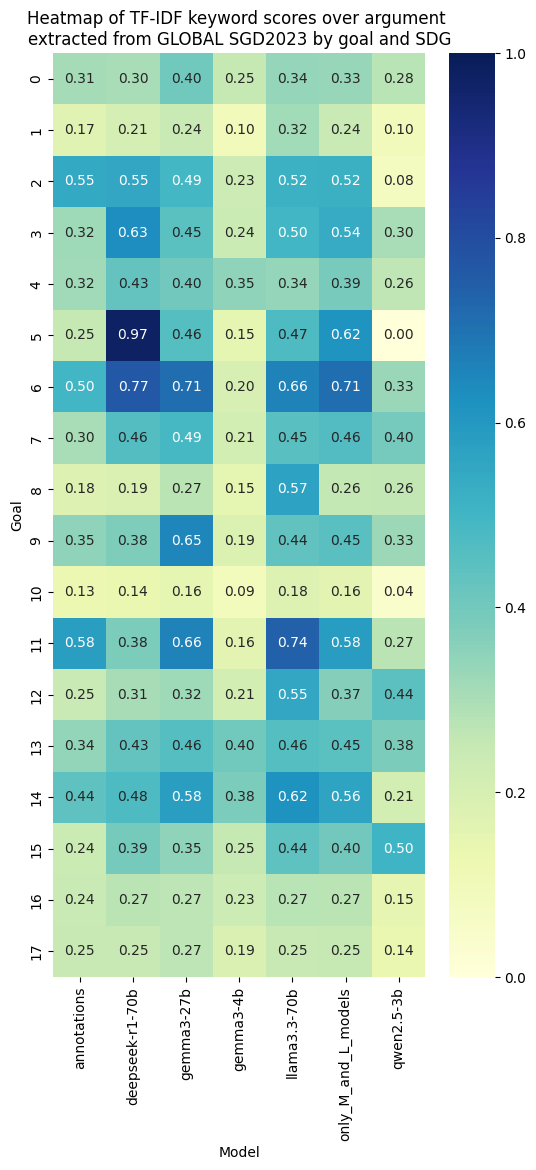

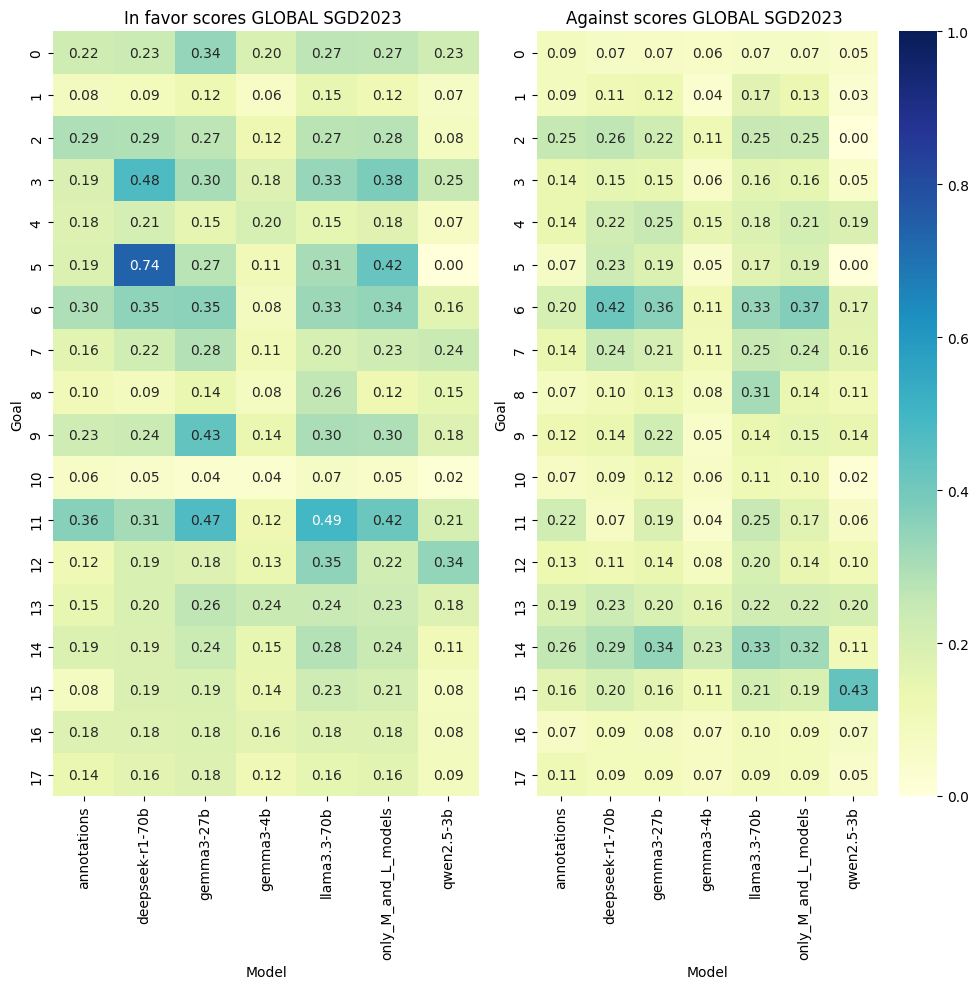

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments No Keywords\\Args"
prefix   = "GLOBAL_SGD2023_"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

c:\Users\cpalo\.conda\envs\pddlgym\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\cpalo\.conda\envs\pddlgym\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc'

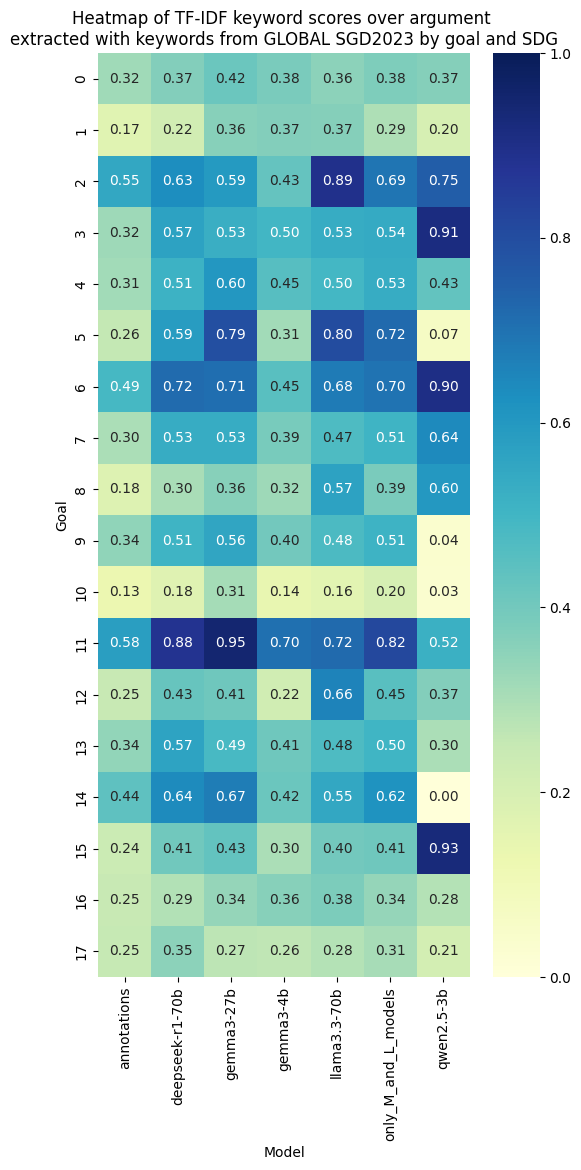

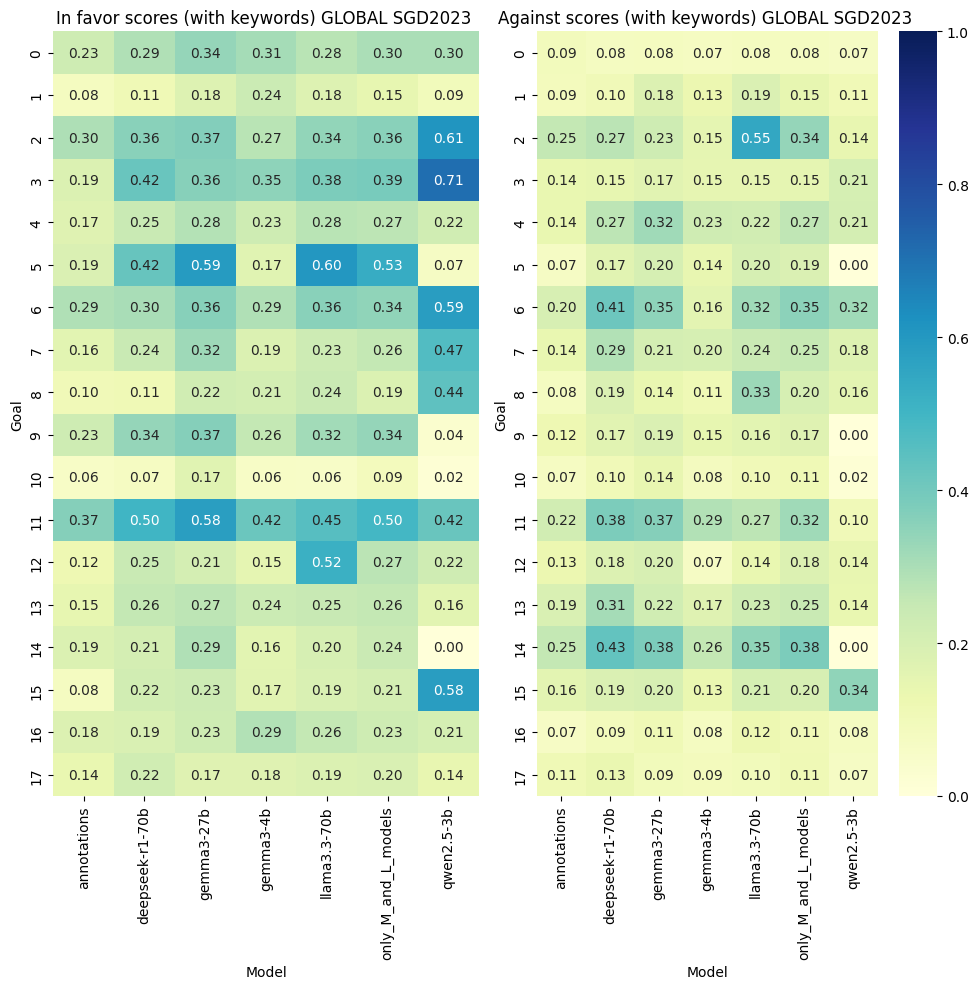

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments Keywords\\Args"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted with keywords from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

#### GLOBAL SGD2024

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments No Keywords\\Args"
prefix   = "GLOBAL_SGD2024_"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments Keywords\\Args"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted with keywords from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

#### GLOBAL SGD2025

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments No Keywords\\Args"
prefix   = "GLOBAL_SGD2025_"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments Keywords\\Args"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted with keywords from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

#### OCDE 2024

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments No Keywords\\Args"
prefix   = "OCDE_2024"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments Keywords\\Args"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted with keywords from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

#### G20 2024

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments No Keywords\\Args"
prefix   = "G20_2024_"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()

In [ ]:
path_args_extracted = "..\\Data\\Processed Arguments Keywords\\Args"

df_scores = calculate_tfidf_scores(path_args_extracted, path_gt_args, prefix)
df_plot = df_scores[df_scores["model"].isin(models + ["annotations"])]

# General
pivot_all = plot_heatmap(
    df_plot,
    value_col="mean_total",
    title=f"Heatmap of TF-IDF keyword scores over argument \nextracted with keywords from {prefix.replace('_', ' ')}by goal and SDG"
)
plt.show()

# In favor/against
fig, axes = plt.subplots(ncols=2, figsize=(10, 10), sharey=False)
plot_heatmap(
    df_plot, value_col="mean_favor",
    title=f"In favor scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[0], vmin=0, vmax=1, cbar=False
)
plot_heatmap(
    df_plot, value_col="mean_against",
    title=f"Against scores (with keywords) {prefix.replace('_',' ')}",
    ax=axes[1], vmin=0, vmax=1
)
fig.tight_layout()
plt.show()